In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_image import HIDImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile, plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

# Create HID Image

In [3]:
gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
gf_path = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(022516ADG_5sec)/C07_RD14-0003-30_31_32_33_34-1,1,1,1,1-M1e-0.315GF-Q1.9_03.5sec.hid'
gf_path_2 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021516ADG_5sec)/D01_RD14-0003-44_45-1,1-M4U15-0.03GF-Q1.3_04.5sec.hid'
gf_path_3 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/E44_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid'
gf_path_4 = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(021716ADG_5sec)/G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid'
local_gf_path = 'resources/data/ProvedIt/A02_RD14-0003-31_32-1;1-M2c-0.03GF-Q2.0_01.15sec.hid'
gf_path_5  = '/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles/5 sec/RD14-0003(020316ADG_5sec)/B10_RD14-0003-39_40-1,2-M3a-0.045GF-Q0.8_02.5sec.hid'

image = HIDImage(
    path=gf_path_5,
    panel=Panel(gf_panel_path),
    size_standard="GENESCAN_600_LIZ",
    include_size_standard=True
)

print(image.data.shape)
print(image.annotation.image.sum())

(6, 4096, 1)
622


### Visualization

In [4]:
# get the profile data
raw_data = get_peak_data(local_gf_path)
raw_data.shape

(6, 9641)

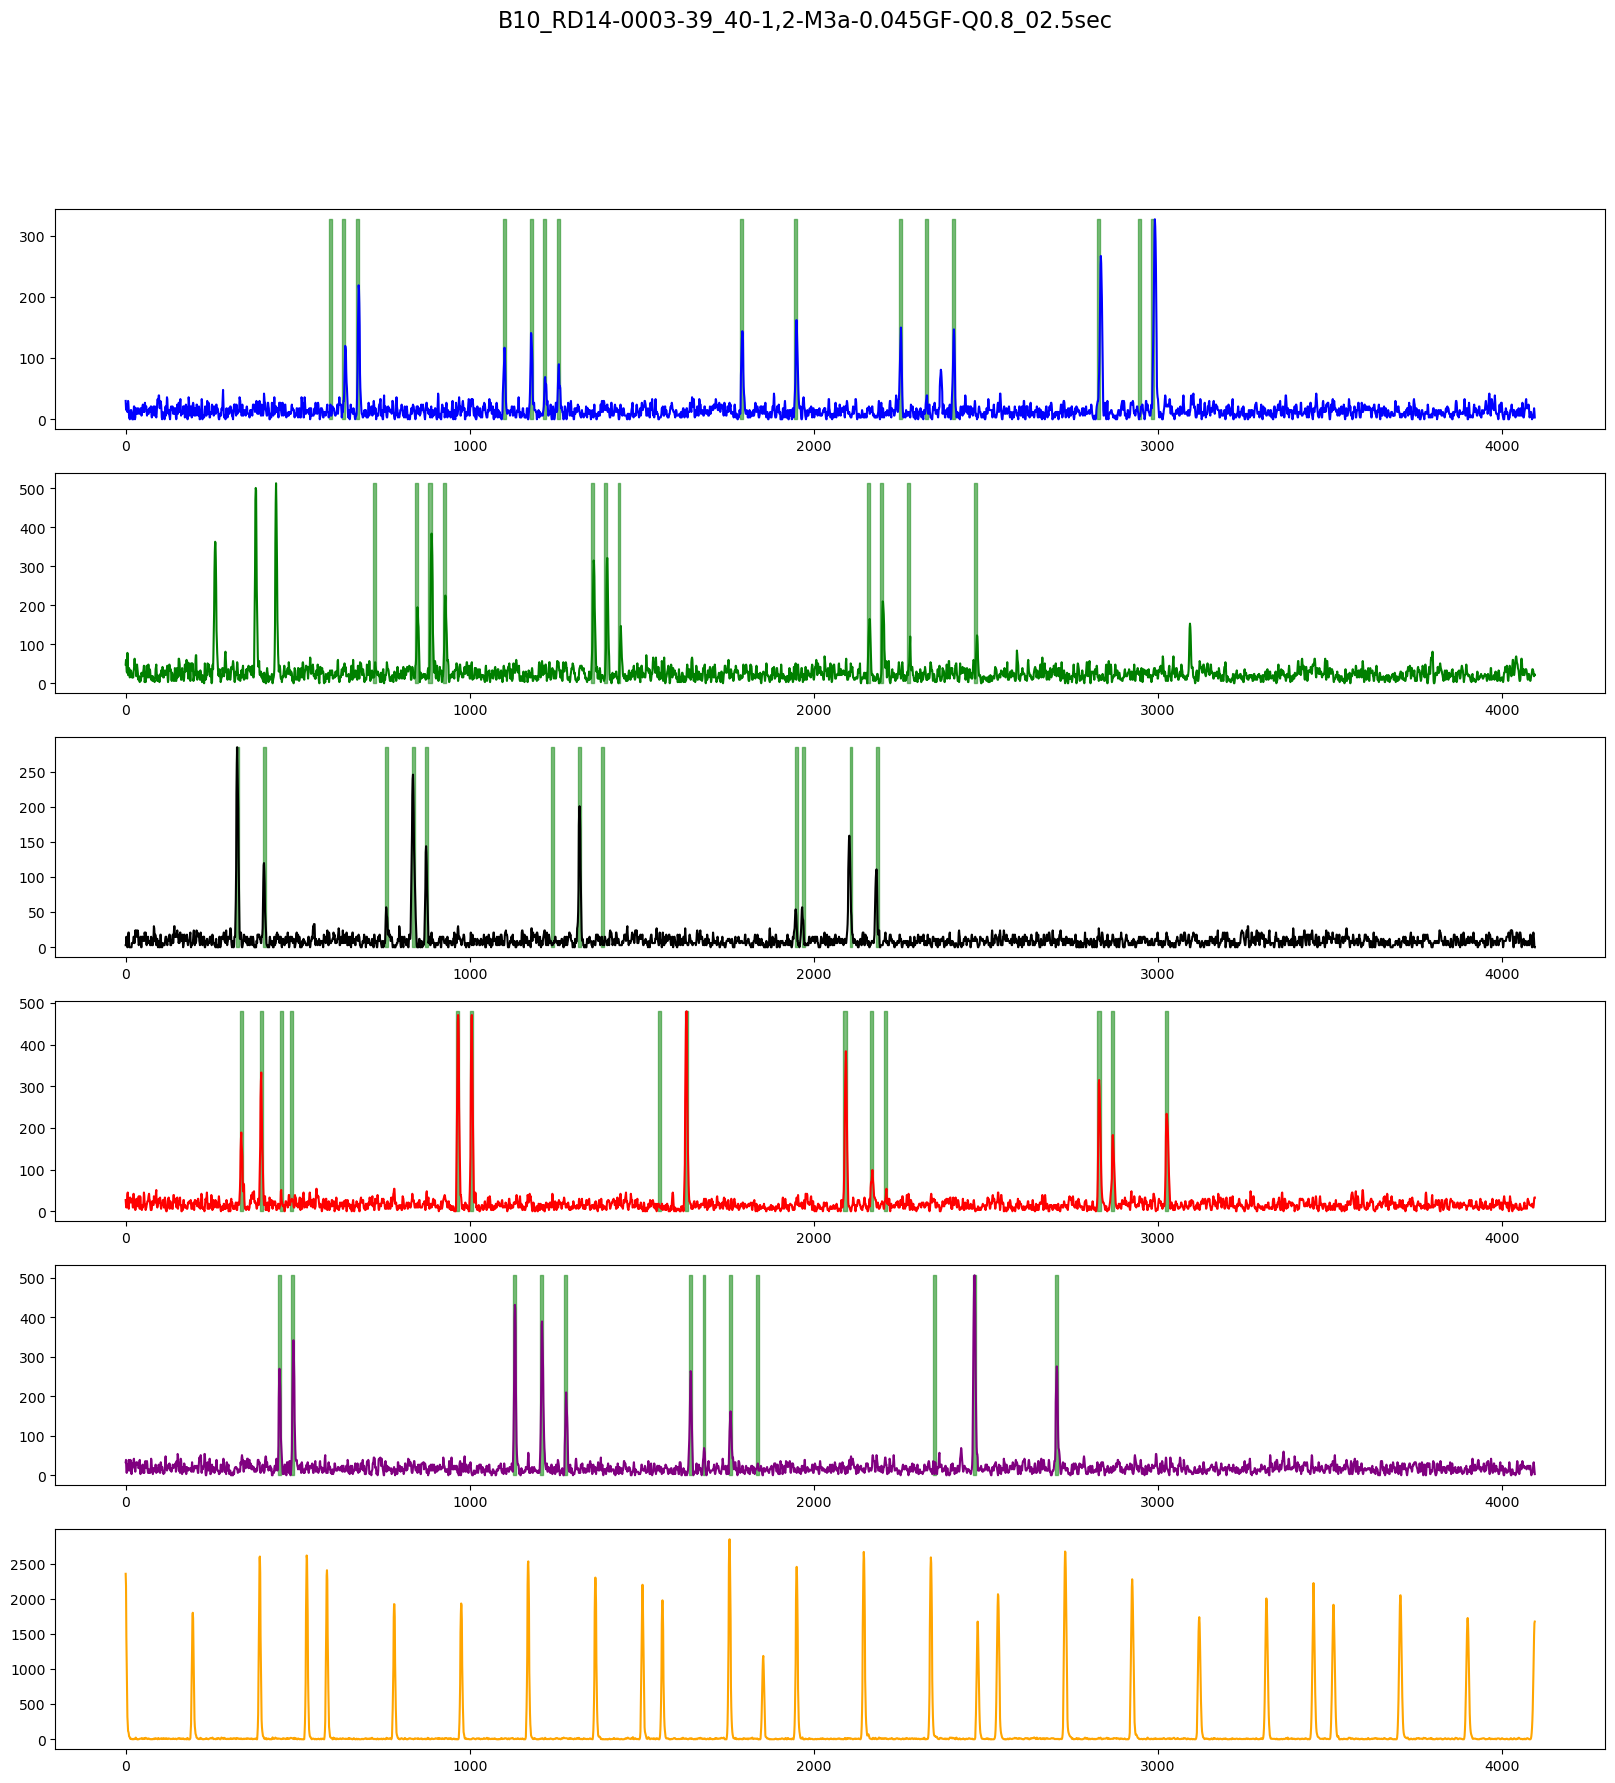

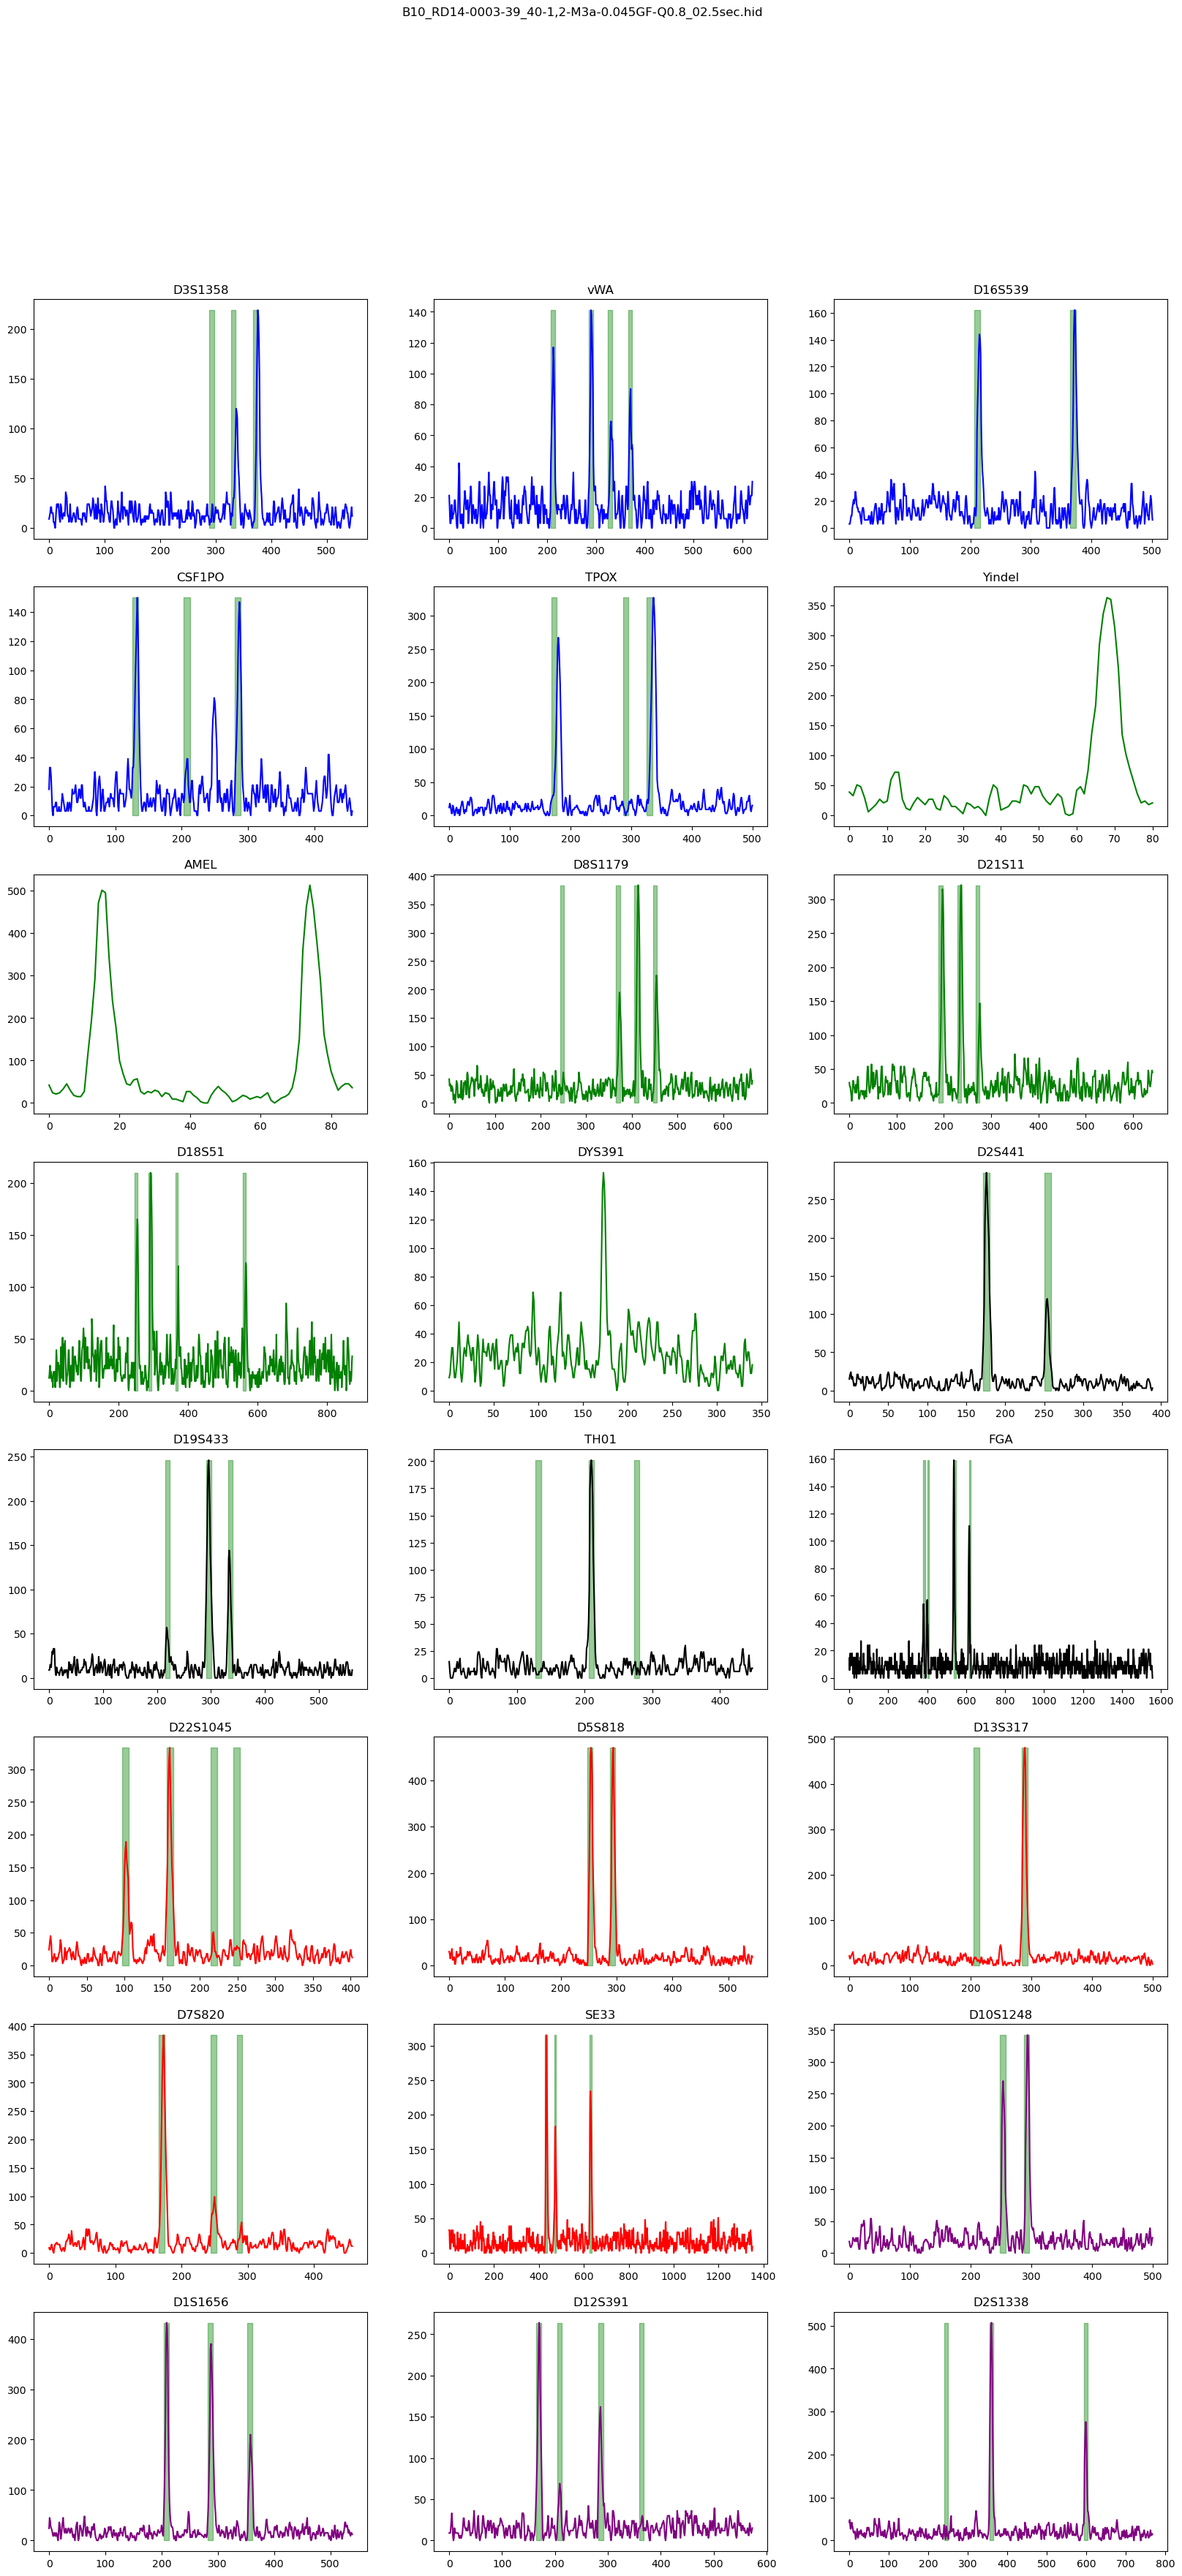

In [5]:
plot_profile(hid_images=[image])
plot_profile_markers(hid_images=[image])

# Plot the scaler

(basepair, scan-point) coords:
- (60, 3700)
- (600, 9455)

In [6]:
image._scaler[0]

60.0

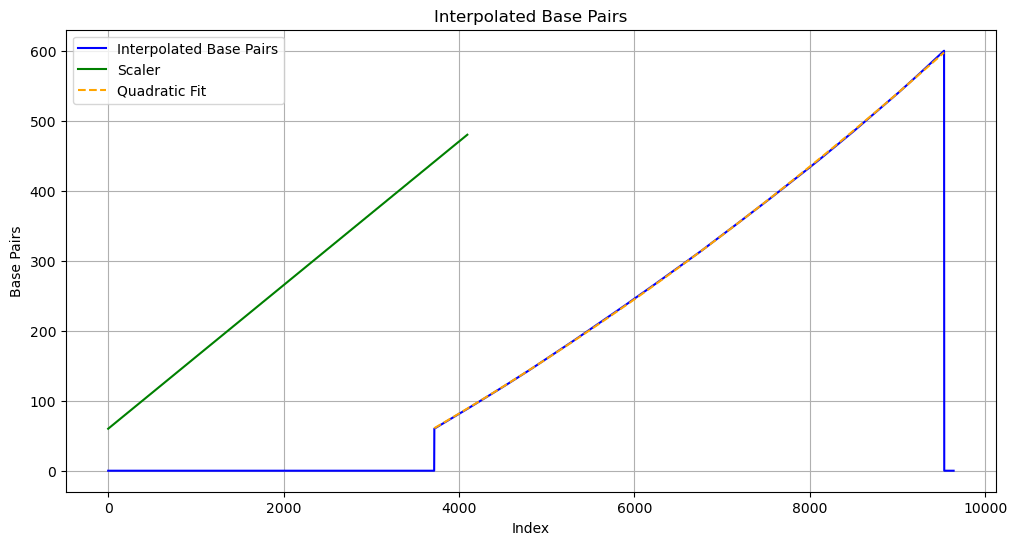

(2.484729124459818,
 array([ 60.6814502 ,  80.52823127, 100.38884204, 114.14034108,
        120.31052306, 140.3478661 , 159.82763317, 179.69067009,
        199.25875013, 213.33264859, 219.27136984, 239.20619947,
        248.99345445, 259.21915582, 279.29681674, 299.70263363,
        314.0793633 , 319.78077553, 339.88154752, 359.99229953,
        380.39406238, 400.49157545, 414.84339693, 420.86370773,
        441.20484095, 461.09041279, 481.22434027, 500.76120731,
        514.55154795, 520.52636938, 540.30362888, 559.64858063,
        578.65048692, 597.51527088]))

In [7]:
# plot the interpolated base pairs
plt.figure(figsize=(12, 6))
plt.plot(image.interpolated_base_pairs, color='blue', label='Interpolated Base Pairs')
plt.plot(image._scaler, color='green', label='Scaler')

x = np.arange(3700, 9456) # np.linspace(3700, 9455, 1000)
f_x = (600 - 60) / (9455 - 3700) * x - 287.2
# plt.plot(x, f_x, color='red', linestyle='--', label='Linear Fit')

coeffs = np.polyfit(image.size_standard_peaks_idxs, image.bps, 2)
fitted = np.polyval(coeffs, image.size_standard_peaks_idxs)
plt.plot(image.size_standard_peaks_idxs, fitted, color='orange', linestyle='--', label='Quadratic Fit')

plt.title("Interpolated Base Pairs")
plt.xlabel("Index")
plt.ylabel("Base Pairs")
plt.grid(True)
plt.legend()
plt.show()

np.max(np.abs(fitted - image.bps)), fitted

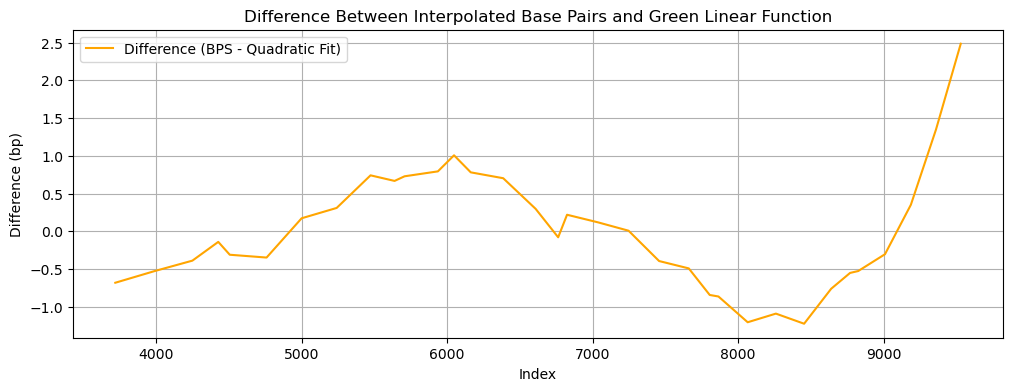

Max absolute difference: 2.48 bp
Mean absolute difference: 0.63 bp


In [8]:
# Show the difference between the interpolated base pairs and the green linear function
# We'll compare over the range 3700 to 9455
ibp = image.interpolated_base_pairs[3700:9456]
diff_1 = ibp - f_x
diff_2 = image.bps - fitted

plt.figure(figsize=(12, 4))
# plt.plot(x, diff_1, color='red', label='Difference (Interpolated - Linear)')
plt.plot(image.size_standard_peaks_idxs, diff_2, color='orange', label='Difference (BPS - Quadratic Fit)')
plt.title("Difference Between Interpolated Base Pairs and Green Linear Function")
plt.xlabel("Index")
plt.ylabel("Difference (bp)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Max absolute difference: {np.max(np.abs(diff_2)):.2f} bp")
print(f"Mean absolute difference: {np.mean(np.abs(diff_2)):.2f} bp")

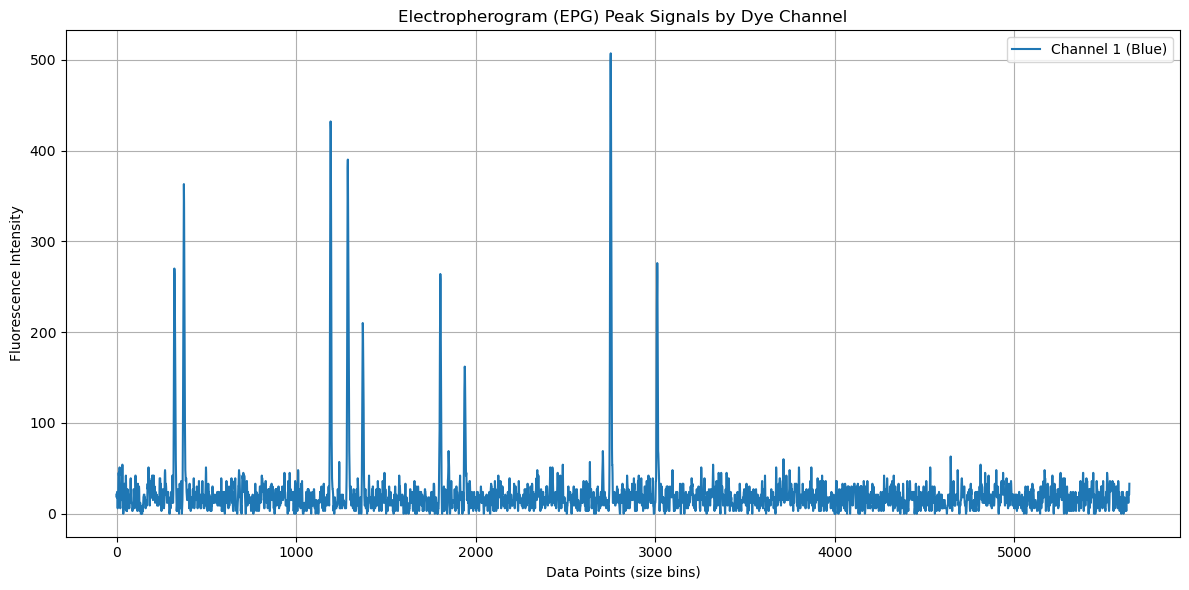

In [9]:
epg = get_peak_data(image.path)[4:5, 4000:] # original shape: (6, 9641)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)

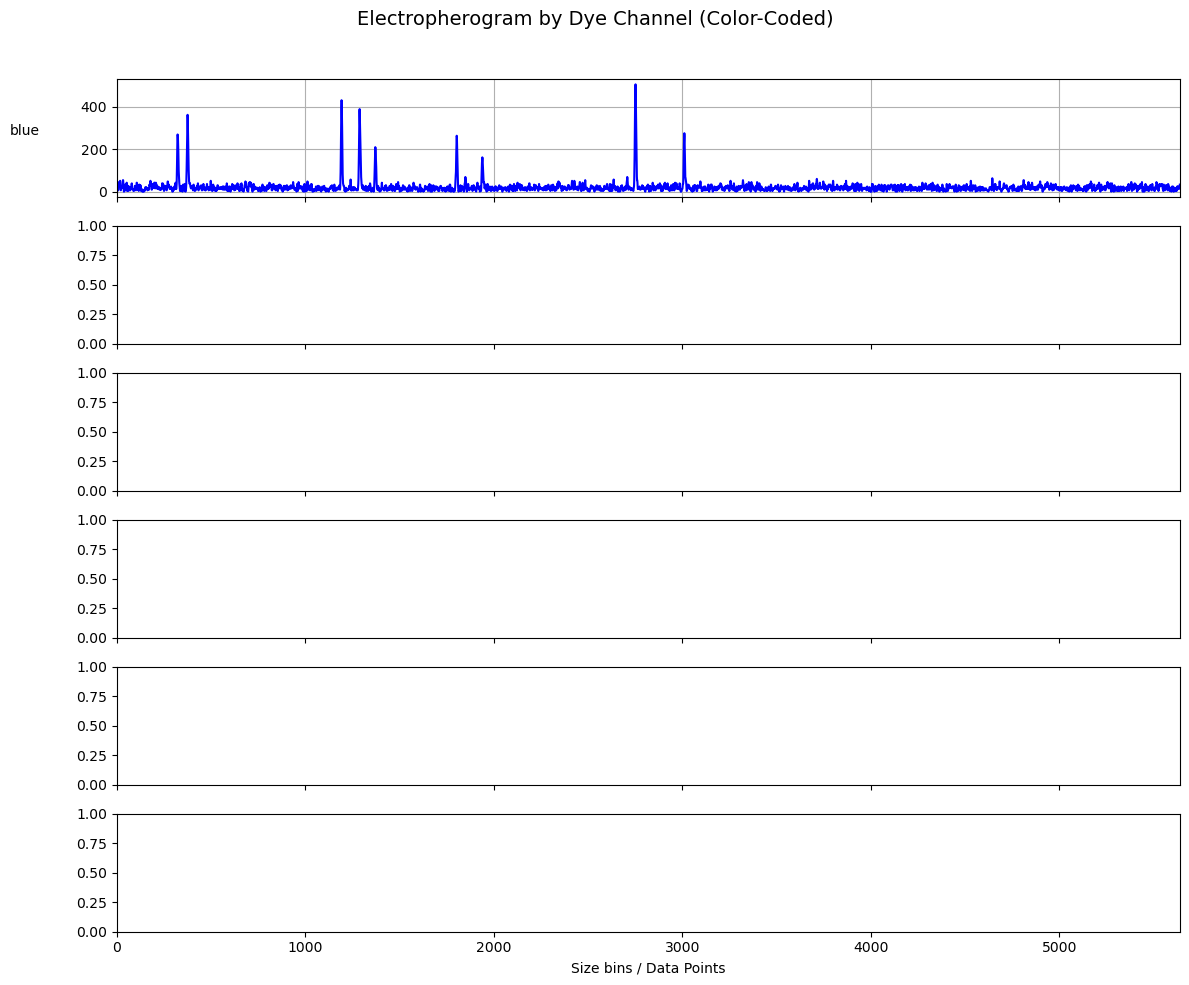

In [10]:
dye_colors = ['blue', 'green', 'gold', 'red', 'purple', 'orange']

fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

for i in range(epg.shape[0]):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_colors[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])
    # axs[i].set_ylim(2, 4)  # Adjust y-limits for better visibility

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [11]:
# # count the different values in the epg array
# unique, counts = np.unique(epg, return_counts=True)
# # print(dict(zip(unique, counts)))
# list(zip(unique, counts))[:30], unique[:20]